# Notebook 7 — TabNet Model

## Why this notebook exists

Baselines (Logistic Regression / Random Forest) are simple.
GA and PSO chose a smaller feature subset.
Now we train **TabNet**, a neural network designed for **tabular** data
(tables of rows and columns), on that winning subset.

TabNet is useful here because:

1. It works well on spreadsheet-style customer data
2. It has built-in **feature importance** (attention)
3. It lets us check whether the GA/PSO subset helps a neural model too

| | |
|---|---|
| **Input** | `X_train/test`, `y_train/test`, `nia_feature_selection_winner.json` |
| **Output** | trained TabNet model, metrics, importance CSV, test probabilities |
| **Why it is needed** | Final deep learning predictor for the project. |

## What is TabNet? (viva-friendly explanation)

Ordinary neural nets treat all columns at once.
**TabNet** looks at a few important features at each step, then moves to
other features in later steps. That “which features to look at” idea is
called **attention**.

Think of it like a careful analyst:

1. First glance at complaints and tenure
2. Then check recency and cashback
3. Combine those signals into a churn probability

### Parameters we set (and what they mean)

| Parameter | Our value | Plain meaning |
|---|---|---|
| `n_d` | 16 | Size of the decision layer (how wide the thinking is) |
| `n_a` | 16 | Size of the attention layer (how it chooses features) |
| `n_steps` | 3 | How many sequential “looks” at the data |
| `gamma` | 1.5 | Controls how much feature reuse is allowed across steps |
| `lambda_sparse` | 1e-4 | Small push toward using fewer features at each step |
| `max_epochs` | 100 | Maximum training rounds |
| `patience` | 15 | Stop early if validation score stops improving |
| `batch_size` | 256 | How many rows are seen in one training update |
| `weights=1` | balanced | Helps with the rare churn class |

In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"
MODEL_FOLDER = "../models"

os.makedirs(FIGURE_FOLDER, exist_ok=True)
os.makedirs(MODEL_FOLDER, exist_ok=True)

X_train = pd.read_csv(CLEAN_FOLDER + "/X_train.csv")
X_test = pd.read_csv(CLEAN_FOLDER + "/X_test.csv")
y_train = pd.read_csv(CLEAN_FOLDER + "/y_train.csv")["Churn"].values
y_test = pd.read_csv(CLEAN_FOLDER + "/y_test.csv")["Churn"].values

with open(CLEAN_FOLDER + "/nia_feature_selection_winner.json", "r", encoding="utf-8") as f:
    winner = json.load(f)

win_feats = winner["winning_features"]
print("NIA winner algorithm:", winner["winner"])
print("Winning feature count:", len(win_feats))
print("Train rows:", len(y_train), "| Test rows:", len(y_test))

NIA winner algorithm: GA
Winning feature count: 17
Train rows: 4504 | Test rows: 1126


## Step 1 — Helper functions

`evaluate_probabilities` turns churn probabilities into metrics.
`train_tabnet` builds one TabNet model, trains it, and returns scores.

In [2]:
def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    """Convert probabilities to 0/1 predictions and compute metrics."""
    predictions = []
    for p in probabilities:
        if p >= threshold:
            predictions.append(1)
        else:
            predictions.append(0)

    metrics = {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
    }
    return metrics, predictions


def train_tabnet(X_tr, y_tr, X_te, y_te, name):
    """Train one TabNet model and evaluate it on the test set."""
    model = TabNetClassifier(
        n_d=16,
        n_a=16,
        n_steps=3,
        gamma=1.5,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={"lr": 0.02},
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type="entmax",
        verbose=0,
        seed=RANDOM_SEED,
    )

    start_time = time.time()
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_te, y_te)],
        eval_metric=["auc", "logloss"],
        max_epochs=100,
        patience=15,
        batch_size=256,
        virtual_batch_size=128,
        weights=1,
    )
    elapsed = time.time() - start_time

    probabilities = model.predict_proba(X_te)[:, 1]
    metrics, predictions = evaluate_probabilities(y_te, probabilities)
    metrics["model"] = name
    metrics["n_features"] = int(X_tr.shape[1])
    metrics["train_time_sec"] = float(elapsed)

    return model, metrics, probabilities, predictions


print("Helper functions ready.")

Helper functions ready.


## Step 2 — Train TabNet twice

1. **Winning subset** (from GA/PSO) — the main model
2. **All features** — a short before/after comparison

If the subset model is close to or better than the full model, GA/PSO helped
by removing noise.

In [3]:
# Winning subset
Xtr_win = X_train[win_feats].values.astype(np.float32)
Xte_win = X_test[win_feats].values.astype(np.float32)

print("Training TabNet on winning subset...")
model_win, metrics_win, proba_win, pred_win = train_tabnet(
    Xtr_win, y_train, Xte_win, y_test, "TabNet_winning_subset"
)
print(metrics_win)

# All features
Xtr_all = X_train.values.astype(np.float32)
Xte_all = X_test.values.astype(np.float32)

print()
print("Training TabNet on all features...")
model_all, metrics_all, proba_all, pred_all = train_tabnet(
    Xtr_all, y_train, Xte_all, y_test, "TabNet_all_features"
)
print(metrics_all)

compare_table = pd.DataFrame([metrics_win, metrics_all])
compare_table.to_json(CLEAN_FOLDER + "/tabnet_metrics.json", orient="records", indent=2)
compare_table[["model", "n_features", "accuracy", "precision", "recall", "f1", "pr_auc"]]

Training TabNet on winning subset...



Early stopping occurred at epoch 88 with best_epoch = 73 and best_val_0_logloss = 0.0763


C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


{'accuracy': 0.9733570159857904, 'precision': 0.8846153846153846, 'recall': 0.968421052631579, 'f1': 0.9246231155778895, 'roc_auc': 0.9963956365272154, 'pr_auc': 0.9837645399357103, 'model': 'TabNet_winning_subset', 'n_features': 17, 'train_time_sec': 74.73984622955322}

Training TabNet on all features...



Early stopping occurred at epoch 89 with best_epoch = 74 and best_val_0_logloss = 0.02916


C:\Users\ishan\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


{'accuracy': 0.9902309058614565, 'precision': 0.9543147208121827, 'recall': 0.9894736842105263, 'f1': 0.9715762273901809, 'roc_auc': 0.9997750787224471, 'pr_auc': 0.998944517887541, 'model': 'TabNet_all_features', 'n_features': 33, 'train_time_sec': 59.749000787734985}


,model,n_features,accuracy,precision,recall,f1,pr_auc
0,TabNet_winning_subset,17,0.973357,0.884615,0.968421,0.924623,0.983765
1,TabNet_all_features,33,0.990231,0.954315,0.989474,0.971576,0.998945


## Step 3 — Save the main model and feature importance

We keep the **winning-subset** TabNet as the project’s neural predictor.

In [4]:
import joblib

save_dir = MODEL_FOLDER + "/tabnet_winning"
os.makedirs(save_dir, exist_ok=True)
model_win.save_model(save_dir + "/model")

joblib.dump(
    {
        "features": win_feats,
        "metrics": metrics_win,
        "winner_algo": winner["winner"],
    },
    MODEL_FOLDER + "/tabnet_meta.joblib",
)

# TabNet built-in feature importance
importance_values = model_win.feature_importances_
importance_rows = []
for i in range(len(win_feats)):
    importance_rows.append([win_feats[i], float(importance_values[i])])

importance_table = pd.DataFrame(importance_rows, columns=["feature", "importance"])
importance_table = importance_table.sort_values("importance", ascending=False)
importance_table.to_csv(CLEAN_FOLDER + "/tabnet_feature_importance.csv", index=False)

np.save(CLEAN_FOLDER + "/tabnet_test_proba_winning.npy", proba_win)

print("Saved TabNet model to", save_dir)
print("Top features by TabNet importance:")
print(importance_table.head(10).to_string(index=False))

Successfully saved model at ../models/tabnet_winning/model.zip
Saved TabNet model to ../models/tabnet_winning
Top features by TabNet importance:
                            feature  importance
                             Tenure    0.226539
               MaritalStatus_Single    0.110900
PreferedOrderCat_Laptop & Accessory    0.084081
                  SatisfactionScore    0.082104
                           Complain    0.074111
                  DaySinceLastOrder    0.073250
                         CouponUsed    0.069790
                    NumberOfAddress    0.048957
                    WarehouseToHome    0.047017
                           CityTier    0.042782


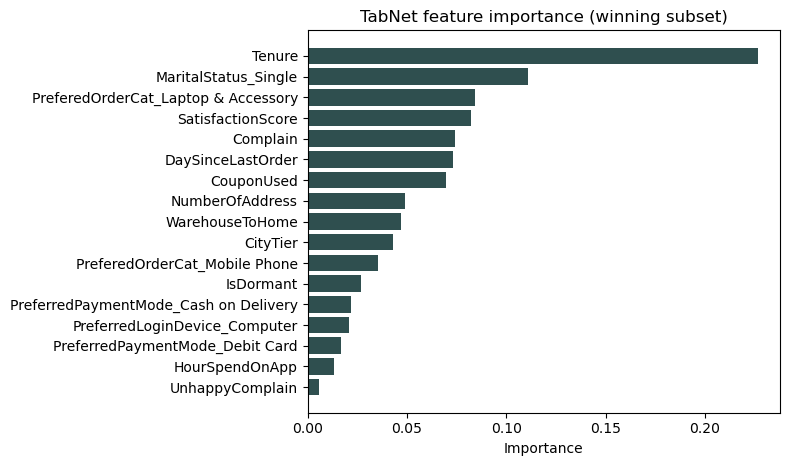

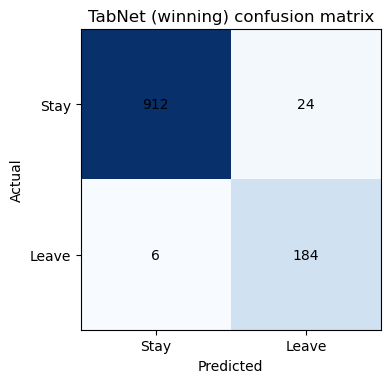

TN: 912 FP: 24 FN: 6 TP: 184


In [5]:
# Feature importance chart
plt.figure(figsize=(8, max(3, 0.28 * len(importance_table))))
plt.barh(
    importance_table["feature"][::-1],
    importance_table["importance"][::-1],
    color="darkslategray",
)
plt.xlabel("Importance")
plt.title("TabNet feature importance (winning subset)")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/7_tabnet_importance.png", dpi=150)
plt.show()

# Confusion matrix for winning model
cm = confusion_matrix(y_test, pred_win)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("TabNet (winning) confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Stay", "Leave"])
plt.yticks([0, 1], ["Stay", "Leave"])
for row in range(2):
    for col in range(2):
        plt.text(col, row, str(cm[row, col]), ha="center", va="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/7_tabnet_confusion.png", dpi=150)
plt.show()

print("TN:", cm[0, 0], "FP:", cm[0, 1], "FN:", cm[1, 0], "TP:", cm[1, 1])

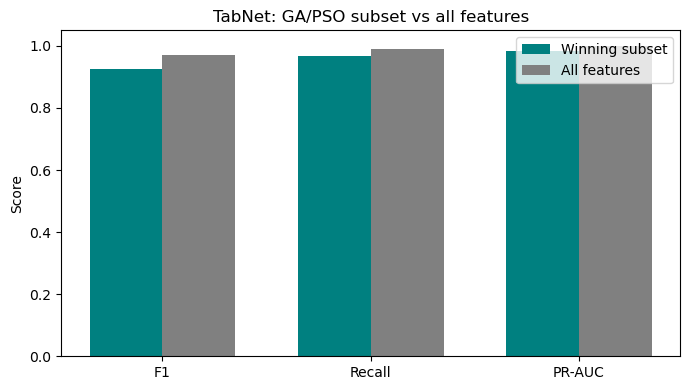

                model  n_features       f1   recall   pr_auc
TabNet_winning_subset          17 0.924623 0.968421 0.983765
  TabNet_all_features          33 0.971576 0.989474 0.998945


In [6]:
# Subset vs all-features comparison on key metrics
keys = ["f1", "recall", "pr_auc"]
labels = ["F1", "Recall", "PR-AUC"]
win_scores = []
all_scores = []
for key in keys:
    win_scores.append(metrics_win[key])
    all_scores.append(metrics_all[key])

x = list(range(len(keys)))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar([i - width / 2 for i in x], win_scores, width=width, label="Winning subset", color="teal")
plt.bar([i + width / 2 for i in x], all_scores, width=width, label="All features", color="gray")
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("TabNet: GA/PSO subset vs all features")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/7_tabnet_metric_compare.png", dpi=150)
plt.show()

print(compare_table[["model", "n_features", "f1", "recall", "pr_auc"]].to_string(index=False))

## Step 4 — Example predictions

A TabNet output is a probability between 0 and 1:

- **0.92** → strongly expects churn → contact this customer
- **0.10** → likely to stay → do not waste a heavy discount

We look at a few test customers, plus the highest-risk and lowest-risk cases.

In [7]:
id_test = pd.read_csv(CLEAN_FOLDER + "/id_test.csv")

example_rows = []
for i in range(8):
    customer_id = int(id_test.loc[i, "CustomerID"])
    actual = int(y_test[i])
    prob = float(proba_win[i])
    pred = int(pred_win[i])

    if pred == 1:
        decision = "Predicted LEAVE"
    else:
        decision = "Predicted STAY"

    if actual == pred:
        result = "correct"
    else:
        result = "wrong"

    example_rows.append([customer_id, actual, round(prob, 3), decision, result])

examples = pd.DataFrame(
    example_rows,
    columns=["CustomerID", "ActualChurn", "P(churn)", "Decision", "Result"],
)
print(examples.to_string(index=False))

# Highest and lowest risk
highest_i = 0
lowest_i = 0
for i in range(1, len(proba_win)):
    if proba_win[i] > proba_win[highest_i]:
        highest_i = i
    if proba_win[i] < proba_win[lowest_i]:
        lowest_i = i

print()
print("Highest risk customer")
print("  CustomerID:", int(id_test.loc[highest_i, "CustomerID"]))
print("  P(churn)  :", round(float(proba_win[highest_i]), 3))
print("  Actual    :", int(y_test[highest_i]))

print()
print("Lowest risk customer")
print("  CustomerID:", int(id_test.loc[lowest_i, "CustomerID"]))
print("  P(churn)  :", round(float(proba_win[lowest_i]), 3))
print("  Actual    :", int(y_test[lowest_i]))

 CustomerID  ActualChurn  P(churn)       Decision  Result
      54007            0       0.0 Predicted STAY correct
      51970            0       0.0 Predicted STAY correct
      54236            0       0.0 Predicted STAY correct
      50106            0       0.0 Predicted STAY correct
      52296            0       0.0 Predicted STAY correct
      54394            0       0.0 Predicted STAY correct
      52952            0       0.0 Predicted STAY correct
      53404            0       0.0 Predicted STAY correct

Highest risk customer
  CustomerID: 51473
  P(churn)  : 1.0
  Actual    : 1

Lowest risk customer
  CustomerID: 52225
  P(churn)  : 0.0
  Actual    : 0


## How predictions flow in the real world

1. A new customer row arrives with the same raw fields
2. Apply the same cleaning steps from notebook 3
3. Keep only the winning feature columns
4. TabNet outputs `P(churn)`
5. If probability is high, send to CX / CRM retention team

**Business meaning:** high-probability churners should get complaint recovery,
onboarding help, or win-back offers before they leave.

## Conclusion of notebook 7

- TabNet is trained on the NIA winning subset and on all features
- We compare F1 / Recall / PR-AUC
- Feature importance shows which drivers TabNet relied on
- Test probabilities are saved for notebook 8

**Files created**

- `models/tabnet_winning/model.zip` (or equivalent TabNet save files)
- `models/tabnet_meta.joblib`
- `data/clean/tabnet_metrics.json`
- `data/clean/tabnet_feature_importance.csv`
- `data/clean/tabnet_test_proba_winning.npy`
- `figures/7_*.png`

**Next:** notebook 8 explains drivers with permutation importance and business insights.